Using Colab cache for faster access to the 'world-happiness-2015-2024' dataset.
Dataset downloaded successfully!
Dataset path: /kaggle/input/world-happiness-2015-2024

CSV Files Found:
world_happiness_2018.csv
world_happiness_2023.csv
world_happiness_2022.csv
world_happiness_2016.csv
world_happiness_2015.csv
world_happiness_2017.csv
world_happiness_2019.csv
world_happiness_2020.csv
world_happiness_2021.csv
world_happiness_2024.csv

First 5 Rows:
   Ranking      Country            Regional indicator Happiness score  \
0      145  Afghanistan                    South Asia          3,6315   
1      112      Albania    Central and Eastern Europe           4,586   
2       84      Argelia  Middle East and North Africa          5,2946   
3      142       Angola            Sub-Saharan Africa          3,7948   
4       29    Argentina   Latin America and Caribbean           6,388   

  GDP per capita Social support  Healthy life expectancy  \
0        2,01215        0,20121                    

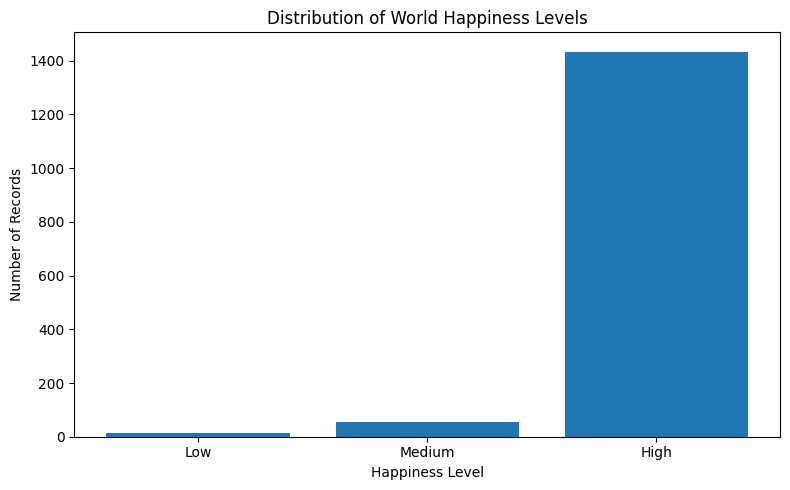

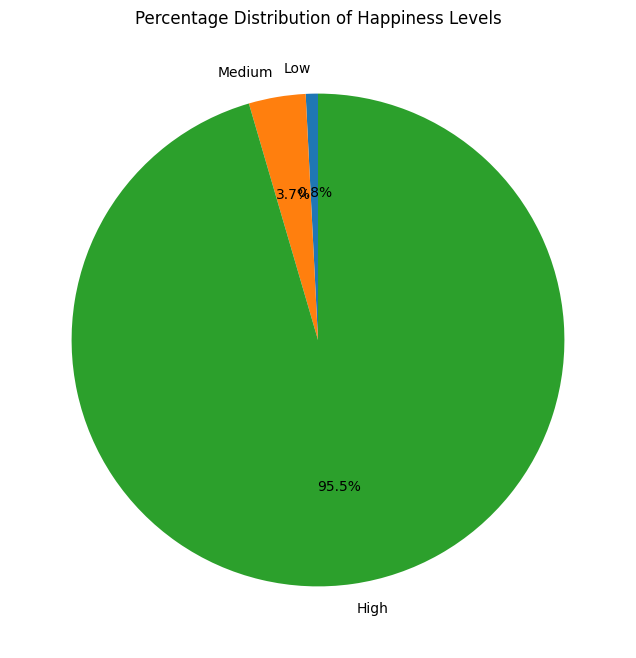

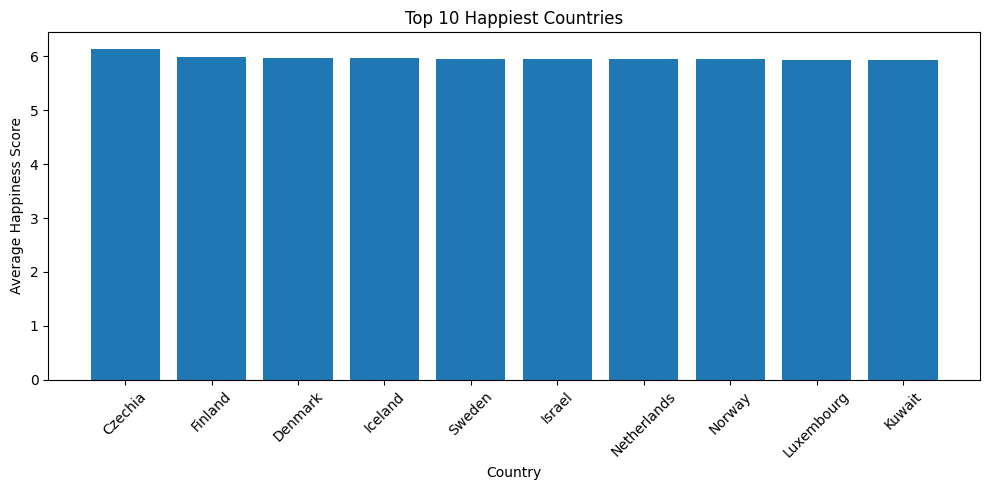


Final Transformed Dataset:
   Ranking      Country            Regional indicator  Happiness score  \
0      145  Afghanistan                    South Asia           3.6315   
1      112      Albania    Central and Eastern Europe           4.5860   
2       84      Argelia  Middle East and North Africa           5.2946   
3      142       Angola            Sub-Saharan Africa           3.7948   
4       29    Argentina   Latin America and Caribbean           6.3880   

   GDP per capita  Social support  Healthy life expectancy  \
0         2.01215         0.20121                     59.0   
1         5.55338         0.55534                     70.0   
2         5.93587         0.59359                     68.0   
3         4.42773         0.44277                     59.0   
4         6.50476         0.65048                     69.0   

   Freedom to make life choices  Generosity  Perceptions of corruption  \
0                       0.11671     0.31964                    0.07937   
1     

In [6]:
# ============================================================
# EXPERIMENT 6A
# DATA IMPORT, TRANSFORMATION AND VISUALIZATION
# WORLD HAPPINESS DATASET 2015-2024
# ============================================================


# ============================================================
# 1. INSTALL AND IMPORT LIBRARIES
# ============================================================

!pip install -q kagglehub

import kagglehub
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


# ============================================================
# 2. IMPORT DATA DIRECTLY FROM KAGGLE
# ============================================================

# Kaggle Dataset:
# https://www.kaggle.com/datasets/yadiraespinoza/world-happiness-2015-2024

path = kagglehub.dataset_download(
    "yadiraespinoza/world-happiness-2015-2024"
)

print("Dataset downloaded successfully!")
print("Dataset path:", path)


# ============================================================
# 3. FIND ALL CSV FILES
# ============================================================

csv_files = glob.glob(
    os.path.join(path, "**", "*.csv"),
    recursive=True
)

# Filter out the 'world_happiness_combined.csv' file if it exists,
# as it might have a different structure or be redundant.
csv_files = [
    f for f in csv_files
    if "combined" not in os.path.basename(f)
]

print("\nCSV Files Found:")

for file in csv_files:
    print(os.path.basename(file))


# ============================================================
# 4. IMPORT AND COMBINE ALL YEARS
# ============================================================

dataframes = []

for file in csv_files:

    # Specify semicolon as the separator
    temp = pd.read_csv(file, sep=';')

    # Store the source file/year
    temp["Year_File"] = os.path.basename(file)

    dataframes.append(temp)


df = pd.concat(
    dataframes,
    ignore_index=True
)


# ============================================================
# 5. DISPLAY DATA
# ============================================================

print("\nFirst 5 Rows:")
print(df.head())

print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 6. DATA TRANSFORMATION
# ============================================================

# Remove completely blank rows
df = df.dropna(how="all")


# Remove duplicate records
df = df.drop_duplicates()


# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Convert columns that should be numeric but have commas as decimal separators
columns_to_convert = [
    'Happiness score',
    'GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption',
    'Ladder score' # Assuming 'Ladder score' is also a numeric score
]

for col in columns_to_convert:
    if col in df.columns:
        # Replace comma with dot and convert to numeric
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce') # 'coerce' will turn unparseable values into NaN


# ============================================================
# 7. IDENTIFY HAPPINESS SCORE COLUMN
# ============================================================

if "Life Ladder" in df.columns:

    score_column = "Life Ladder"

elif "Ladder score" in df.columns:

    score_column = "Ladder score"

elif "Happiness Score" in df.columns:

    score_column = "Happiness Score"

else:

    raise ValueError(
        "Happiness score column not found."
    )


print("\nHappiness Score Column:", score_column)


# ============================================================
# 8. IDENTIFY COUNTRY COLUMN
# ============================================================

if "Country name" in df.columns:

    country_column = "Country name"

elif "Country" in df.columns:

    country_column = "Country"

else:

    raise ValueError(
        "Country column not found."
    )


print("Country Column:", country_column)


# ============================================================
# 9. HANDLE MISSING VALUES
# ============================================================

# Numerical columns
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numeric_columns:

    df[column] = df[column].fillna(
        df[column].median()
    )


# Categorical columns
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:

    if df[column].isnull().sum() > 0:

        df[column] = df[column].fillna(
            "Unknown"
        )


print("\nMissing values after transformation:")
print(df.isnull().sum())


# ============================================================
# 10. CREATE HAPPINESS CATEGORY
# ============================================================

# Attempt to create happiness levels using pd.qcut
try:
    df["Happiness_Level"] = pd.qcut(
        df[score_column],
        q=3,
        labels=[
            "Low",
            "Medium",
            "High"
        ],
        duplicates='drop' # Added to handle non-unique bin edges
    )
except ValueError as e:
    # If qcut fails due to too few unique bins (e.g., ValueError: Bin labels must be one fewer than the number of bin edges),
    # fall back to pd.cut to ensure 3 categories are created.
    print(f"Warning: pd.qcut failed to create 3 distinct quantile bins: {e}")
    min_val = df[score_column].min()
    max_val = df[score_column].max()

    if pd.isna(min_val) or pd.isna(max_val) or min_val == max_val:
        # Handle cases where the score column is constant or all NaN
        df["Happiness_Level"] = "Overall" # Assign a single category
        print("Warning: Score column is constant or NaN, assigned 'Overall' category.")
    else:
        # Create approximately equal-width bins for 3 categories
        df["Happiness_Level"] = pd.cut(
            df[score_column],
            bins=3,
            labels=["Low", "Medium", "High"],
            include_lowest=True
        )
        print("Falling back to pd.cut with 3 equal-width bins.")


# ============================================================
# 11. BAR CHART
# DISTRIBUTION OF HAPPINESS LEVEL
# ============================================================

happiness_count = (
    df["Happiness_Level"]
    .value_counts()
    .reindex(
        ["Low", "Medium", "High"]
    )
)


plt.figure(figsize=(8,5))

plt.bar(
    happiness_count.index,
    happiness_count.values
)

plt.xlabel("Happiness Level")

plt.ylabel("Number of Records")

plt.title(
    "Distribution of World Happiness Levels"
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. PIE CHART
# HAPPINESS LEVEL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,8))

plt.pie(
    happiness_count.values,
    labels=happiness_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Percentage Distribution of Happiness Levels"
)

plt.show()


# ============================================================
# 13. TOP 10 HAPPIEST COUNTRIES
# ============================================================

top_countries = (
    df.groupby(country_column)[score_column]
      .mean()
      .sort_values(
          ascending=False
      )
      .head(10)
)


plt.figure(figsize=(10,5))

plt.bar(
    top_countries.index,
    top_countries.values
)

plt.xlabel("Country")

plt.ylabel(
    "Average Happiness Score"
)

plt.title(
    "Top 10 Happiest Countries"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# ============================================================
# 14. FINAL DATASET
# ============================================================

print("\nFinal Transformed Dataset:")
print(df.head())

print("\nFinal Dataset Shape:")
print(df.shape)